# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the mortality observed in Belgium. In the second part of the project, you try to predict the electricity consumption in Belgium using climate variables.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “Hackathon” on Moodle and the subsection “Remise Hackathon 1”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Félix Harvey, 46772400

Part. 2:

Part. 3: Maxine Bracque, 70272400


Part. 4:

Part. 5:

Part. 6:

# Mortality and climate

In this section, we analyze the relationship between mortality, age groups, and seasons in Belgium using publicly available data from Statbel (see https://statbel.fgov.be/en/about-statbel/what-we-do/visualisations/mortality). The dataset contains the number of deaths recorded over time, disaggregated by age group and observed across different seasons. The objective is to study temporal patterns in mortality and assess the role of seasonal effects. 

## 1. Basic statistics

**1.1)** Load the dataset mortality_climate.csv. Convert the variables *season* and *CD_AGEGROUP* into a categorical variable. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.stats as stats
from scipy.stats import poisson, nbinom

doc_morta = pd.read_csv('mortality_climate.csv')

doc_morta['season'] = doc_morta['season'].astype('category')

ordre_age = ['0-24', '25-44', '45-64', '65-74', '75-84', '85+']

doc_morta['CD_AGEGROUP'] = pd.Categorical(doc_morta['CD_AGEGROUP'], categories=ordre_age, ordered=True)

**1.2)** Plot the evolution of the number of deaths (*MS_NUM_DEATH*) with respect to age group. What do you observe?

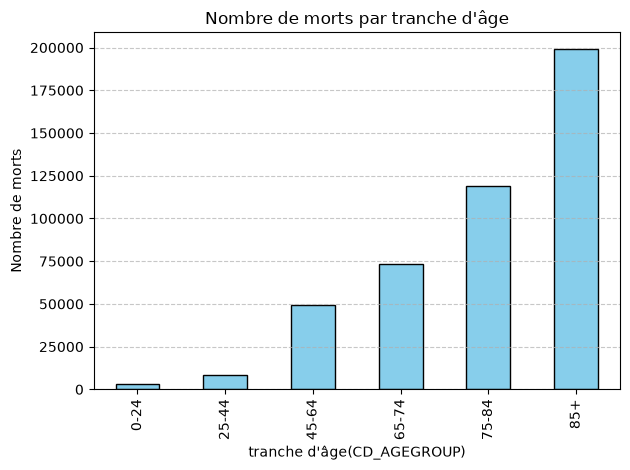

In [13]:
deaths_per_age = doc_morta.groupby('CD_AGEGROUP', observed=False)['MS_NUM_DEATH'].sum()



deaths_per_age.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')
plt.title("Nombre de morts par tranche d'âge")
plt.xlabel("tranche d'âge(CD_AGEGROUP)")
plt.ylabel('Nombre de morts')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()

plt.show()

Comments: Le diagramme en barres représente le nombre total de décès en fonction de la tranche d'âge. On observe une augmentation globale du nombre de décès avec l'âge. Les catégories les plus jeunes présentent un nombre de décès relativement faible, tandis que les catégories plus âgées concentrent la majorité des décès observés.

La tranche des 85 ans et plus est celle qui compte le plus de décès, avec environ 200 000, suivie de celle des 75–84 ans, avec environ 120 000. À l'inverse, la tranche des 0–24 ans présente le nombre de décès le plus faible, avec environ 3 000. L'augmentation devient particulièrement marquée à partir de 45 ans.

Ces observations sont compatibles avec une augmentation de la mortalité aux âges avancés. Il faut toutefois rester prudent dans l'interprétation, car les valeurs représentées sont des nombres absolus et ne tiennent pas compte de la taille de chaque tranche d'âge. Pour comparer le risque de décès entre les groupes, il serait plus pertinent d'utiliser des taux de mortalité calculés par rapport à la population de chaque tranche d'âge.


**1.3)** Do a scatter plot of the number of deaths (*MS_NUM_DEATH*) by age group.

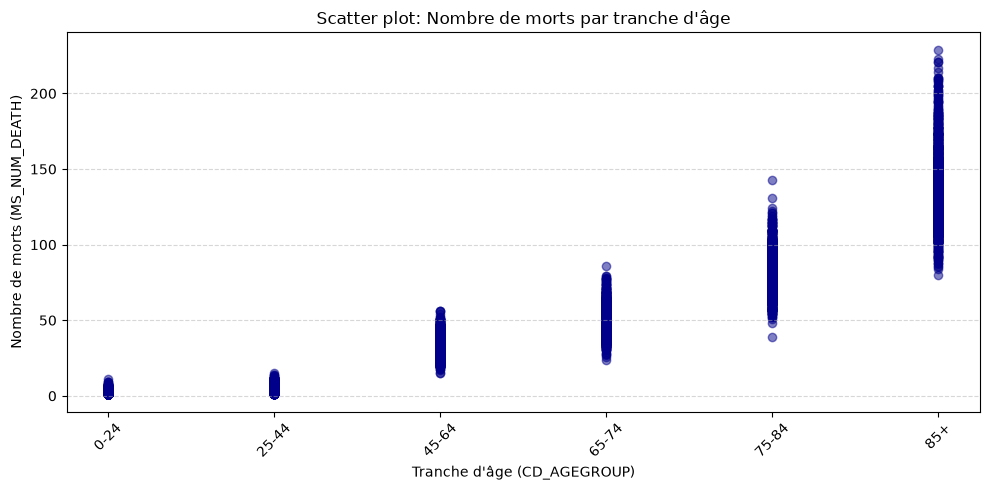

In [16]:
ordre_age = ['0-24', '25-44', '45-64', '65-74', '75-84', '85+']

plt.figure(figsize = (10,5))

categories = pd.Categorical( doc_morta['CD_AGEGROUP'].astype(str), categories=ordre_age, ordered=True )

plt.scatter(
    categories.codes, 
    doc_morta['MS_NUM_DEATH'],
    alpha = 0.5,
    color = 'darkblue'
    )
plt.title("Scatter plot: Nombre de morts par tranche d'âge")
plt.xlabel("Tranche d'âge (CD_AGEGROUP)")
plt.ylabel("Nombre de morts (MS_NUM_DEATH)")
plt.xticks(ticks=range(len(ordre_age)), labels=ordre_age, rotation=45 )#Ça rend l'axe des abscisses plus lisible
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()


Comments: Ce scatter plot représente le nombre quotidien de décès en fonction de la tranche d'âge, sur la période couverte par le jeu de données. Chaque point correspond au nombre de décès enregistrés pour une tranche d'âge à une date donnée.

On observe une tendance générale à l'augmentation du nombre de décès avec l'âge. Les tranches les plus jeunes présentent des valeurs relativement faibles, tandis que les tranches les plus âgées, notamment les 75–84 ans et les 85 ans et plus, présentent des valeurs nettement plus élevées.

La dispersion verticale des points permet également d'observer les variations quotidiennes du nombre de décès au sein de chaque tranche d'âge. Les valeurs des tranches les plus âgées semblent plus dispersées en valeur absolue, ce qui peut notamment être lié à leur nombre de décès quotidien plus important.

Ces observations montrent une association entre la tranche d'âge et le nombre quotidien de décès enregistrés. Cependant, le graphique ne permet pas à lui seul de comparer le risque individuel de décès entre les tranches d'âge, car il ne tient pas compte de la taille de la population de chaque groupe.


## 2. Fit of distributions

**2.1)** For the 45–64 age group and the winter season only, fit both a Poisson and a Negative Binomial distribution to the variable 'MS_NUM_DEATH' using a maximum likelihood approach. Plot histograms overlaid with the fitted probability mass functions. Compare the log-likelihoods and select the most appropriate distribution.

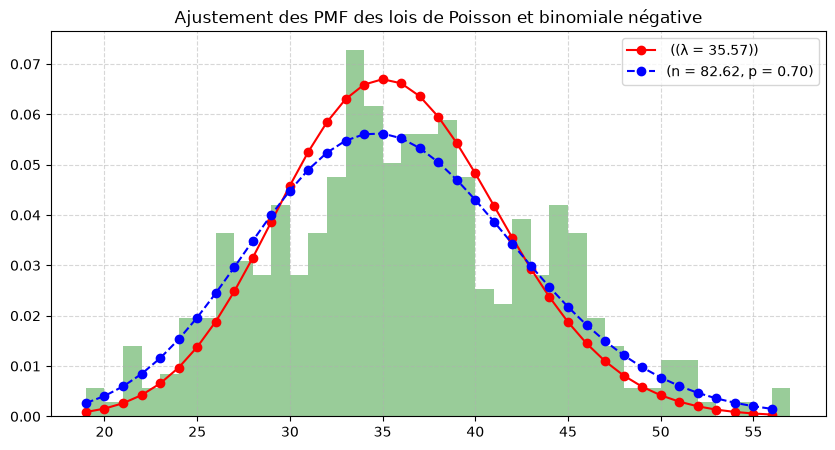

Log-vraisemblance Poisson : -1219.3605439541716
Log-vraisemblance binomiale négative : -1206.538614693794
La loi binomiale négative est préférable.


In [19]:
data = doc_morta[(doc_morta['CD_AGEGROUP'] == '45-64') & (doc_morta['season'] == 'winter')]['MS_NUM_DEATH']
if (len(data) == 0):
    print("Aucune donnée ne satisfait à ces critères")


else:
    #fonction à minimiser
    def moins_log_vraisembleance(params, y):
        n,p = params
        return -np.sum(nbinom.logpmf(y, n, p))


    data_min = data.min()
    data_max = data.max()

    #poisson (E = lambda = Var)
    lambda_experimental = data.mean()
    var = data.var()

    p_devine = lambda_experimental/var
    n_devine = -lambda_experimental ** 2/(lambda_experimental - var)

    ans = minimize(moins_log_vraisembleance, x0 = [n_devine, p_devine], args = (data,), bounds = [(1e-5, None), (1e-5, 0.99999) ])
    n_bin, p_bin = ans.x

    l_poisson = poisson.logpmf(data, mu = lambda_experimental)

    x_s = np.arange(int(data_min), int(data_max) + 1, )
    #Calcul de F(X)
    pmf_poisson = poisson.pmf(x_s, mu = lambda_experimental)


    #binomiale Négative
    
    pmf_binomiale = nbinom.pmf(x_s, n_bin , p_bin)

    #afficher les données
    plt.figure(figsize = (10, 5))
    plt.hist(data, bins = range(int(data_min), int(data_max) + 2), density = True, color = 'green', alpha = 0.4)
    plt.plot(x_s, pmf_poisson, color = 'red', marker = 'o', linestyle = '-', label = f' ((λ = {lambda_experimental:.2f}))')
    plt.plot(x_s, pmf_binomiale, color = 'blue', marker = 'o', linestyle = '--', label = f'(n = {n_bin:.2f}, p = {p_bin:.2f})')
    plt.legend()
    plt.title("Ajustement des PMF des lois de Poisson et binomiale négative")
    plt.grid(True, linestyle = '--', alpha = 0.5)
    plt.show()


# Calcul des log-vraisemblances
log_vraisemblance_poisson = np.sum(poisson.logpmf(data, mu=lambda_experimental))

log_vraisemblance_binomiale = np.sum(nbinom.logpmf(data, n_bin, p_bin))

print("Log-vraisemblance Poisson :", log_vraisemblance_poisson)
print("Log-vraisemblance binomiale négative :", log_vraisemblance_binomiale)

if log_vraisemblance_poisson > log_vraisemblance_binomiale:
    print("La loi de Poisson est préférable.")
else:
    print("La loi binomiale négative est préférable.")

Comments: Le graphique représente la distribution du nombre de décès (MS_NUM_DEATH) pour le groupe d’âge des 45 à 64 ans durant la saison hivernale. L’histogramme vert montre la distribution des données observées, tandis que la courbe rouge représente la fonction de masse de probabilité (PMF) de la loi de Poisson et la courbe bleue en pointillés celle de la loi binomiale négative. Les paramètres des deux distributions ont été estimés afin de les ajuster au mieux aux données.

On remarque que les deux distributions suivent globalement la forme de l’histogramme, avec une concentration des observations autour de 30 à 40 décès. Cependant, la loi de Poisson présente un pic plus marqué, tandis que la loi binomiale négative est plus étalée. Cette dernière permet donc de mieux prendre en compte une dispersion plus importante des données. Les deux modèles semblent relativement proches, mais ils ne représentent pas exactement de la même manière les fréquences observées.

Pour déterminer quel modèle s’ajuste le mieux aux données, nous avons comparé leurs log-vraisemblances. Celle de la loi de Poisson est de -1219,36, tandis que celle de la loi binomiale négative est de -1206,54. Comme la log-vraisemblance de la loi binomiale négative est plus élevée, elle présente un meilleur ajustement selon ce critère. Nous retenons donc la loi binomiale négative comme le modèle le plus approprié parmi les deux distributions étudiées.

# 3. Regression

We now aim to assess whether seasonality has an impact on the number of deaths. We consider the following linear model:
$$\log(Y_i) = \beta_0 + \beta_1 X^S_{i1} + \cdots + \beta_3 X^S_{i3} + \beta_4 X^{age}_{i1} + \cdots + \beta_8 X^{age}_{i5}  + \varepsilon_i.$$

where $Y_i$ denotes the number of deaths, $X^S_{ij}$ are dummy variables representing the different seasons, $X^{age}_{ij}$ are dummy variables representing the different age groups, and $\varepsilon_i \sim N(0, \sigma^2)$. 

**3.1)** Why is it more appropriate to use a linear regression on $\log(Y)$ rather than directly on $Y$?

Comments:

**3.2)** Perform a linear regression of the number of deaths on the seasonal and group age covariates. Use the `OLS` function from the *statsmodels* package. Make sure to convert the variable *season* and *CD_AGEGROUP* into dummy variables before fitting the model.

Does seasonality have a significant impact on mortality? Is the mortality similar for each age group? 

In [ ]:
# Code here


Comments: 

## 4. Hypothesis test 

We now investigate whether mortality decreases over time by comparing mortality in summer in 2022 and 2025. To this end, we aim to perform the following hypothesis test:

$$
H_0 : \mu_{2022} = \mu_{2025},
$$

$$
H_1 : \mu_{2022} \neq \mu_{2025}.
$$

**4.1)** Create two subsets of the original dataset corresponding to the years 2022 and 2025, respectively.

In [ ]:
# Code here


**4.2)** For the 85+ age group, perform a Student’s t-test to compare mortality between 2022 and 2025 **in summer**. Check whether the assumptions required to apply this test are satisfied.

In [ ]:
# Code here


Comments:

**4.3)** Explain what the Wilcoxon test is. Why could it be relevant in our setting?

Comments: 

**4.4)** For the 85+ age group, perform a Wilcoxon test to compare mortality between 2022 and 2025 **in summer**. What do you conclude?

In [ ]:
# Code here


Comments:

**4.5)** Perform the Wilcoxon test but now for the 25–44 age group and the **summer**. What do you conclude in this case?

In [ ]:
# Code here 


Comments: 

# Electricity Consumption and Climate

In this section, we aim to predict electricity consumption using past consumption values and climatic variables. We rely on data provided by ELIA (see https://opendata.elia.be/explore/dataset/ods003/information/?sort=datetime), which records total electricity consumption in Belgium at a 15-minute frequency, and meteorological data from the Royal Meteorological Institute (IRM) (see https://www.meteo.be/fr/services/donnees), which provides daily average temperature observations over Belgium.

The goal is to build a predictive model for electricity demand based on its recent history and weather conditions. From a practical perspective, such forecasting is highly relevant for energy providers and grid operators, as accurately anticipating electricity demand one week ahead helps optimize production planning, ensure grid stability, and reduce operational costs.

## 5. Forecasting 

The goal is to predict electricity consumption at time $t$ using its past values and climate features. Let $Y_t$ denote electricity consumption at time $t$. We consider the following regression model:

$$Y_t = \beta_0 + \beta_1 Y_{t-7Days} + \beta_2 \bar{T}_{t-7Days} + \beta_3 \bar{T}_{t-7Days}^2 + \varepsilon_t,$$

where $Y_{t-7Days}$ denotes electricity consumption observed 7 days earlier, $\bar{T}_{t-7Days}$ is the average temperature observed 7 days earlier$^1$, and $\varepsilon_t \sim \mathcal{N}(0,\sigma^2)$ is an error term.

$^1$ The average temperature is measured at a daily frequency; therefore, $\bar{T}_{t-7Days}$ is constant for all time points $t$ within the same day.

**5.1)** Load the dataset *electricity_climate.csv* and construct the dataset required to perform the regression.

**Warning:** the data are observed at 15-minute intervals.

To build the regression dataset, each row must contain:
- electricity consumption at time $t$: $Y_t$,
- electricity consumption at time $t - 7$ days: $Y_{t-7Days}$,
- temperature at time $t - 7$ days: $\bar{T}_{t-7Days}$,
- the squared temperature at time $t - 7$ days: $\bar{T}_{t-7Days}^2$.

In [ ]:
# Code here 


**5.2)** Split the dataset into a training set (first 75%) and a test set (last 25%).  Use the `OLS` function from the *statsmodels* package to fit linear regression model using only $Y_{t-7Days}$ as explanatory variable.

Analyze the regression output, discuss the statistical significance and performance of the model.

In [ ]:
# Code here 


Comments:

**5.3)** Repeat the regression by including the climate variables in the model.

Are the climate variables statistically significant in explaining electricity consumption 7 days ahead?

In [ ]:
# Code here


Comments: 

**5.4)** Compute the MAE and RMSE on the test set for both models: with and without climate variables.

Does the inclusion of climate variables improve the predictive performance of the model?

In [ ]:
# Code here 


Comments: 

**5.5)** For the model including climate variables, plot the predicted electricity consumption versus the true consumption on the test set. Then, produce a second plot focusing only on the first 7 days of the test set.

In [ ]:
# Code here 


Comments: